# Barotropic Gyre CNN Emulation

This notebook trains a convolutional neural network to emulate short-term MITgcm barotropic gyre states from model snapshots. It predicts an increment from the current state to a future state. 

## Motivation

### Science Question
Can we emulate an ocean state estimate model just using MITgcm outputs using UNet? This matters because a successful emulator could make repeated high-resolution ocean-state experiments much cheaper than rerunning the full numerical model. In this notebook, the first goal is to test whether a CNN can learn 6-hour state transitions for velocity and sea-surface height fields.

### Background 
This forms the first step in a my thesis project to eventually emulate ice-ocean interactions in the Artic. The barotropic gyre is a simplified, wind stress forced ocean model that captures fundamental ocean dynamics: wind forcing driving ocean circulation, thus adjusting the velocity and sea-surface height of the ocean. By learning to emulate this case, I hope to be able to build up to more complex ocean models. 

## Notebook Setup

Import the relevant Python and PyTorch packages used throughout the notebook.


In [23]:
import numpy as np
import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time

## Data

The dataset comes from MITgcm barotropic gyre output files, I model I personally ran separately outside of the included. Each snapshot is a 62 x 62 grid. The notebook loads zonal velocity `U`, meridional velocity `V`, and sea-surface height `Eta`, then stacks them into a tensor with shape `(time, channel, y, x)`. Only the first third of the run is used here to focus on the first year of data, as the ocean state has most of its dynamic behavior in the first year, with subsequent periods of time being stuck in a mostly steady state. The dataset is then split into training and testing sets, with 80% of the data used for training and 20% for testing.

The following code block will be skipped, as I didnt include the source data files from MITgcm in this repo, but I have created another block for pulling the data from google drive instead, so it can be run on Colab. 

In [ ]:
# #code for local usage, loading directly from MITgcm output files, skipped when running in Colab. 

# n_rows, n_cols = 62, 62
# # model_path is the directory where the MITgcm output files (U.*.data and V.*.data) are located
# model_path = '/Users/cool/Workspace/MLML/ms274_fall2025/MITgcm/verification/tutorial_barotropic_gyre/run'

# def load_mitgcm_binary(file_path):
#     file = os.path.join(file_path)
#     grid = np.fromfile(file, '>f4').reshape((n_rows, n_cols))
#     return grid

# # Get list of all U and V files, sorted by iteration number
# u_files = sorted(glob.glob(model_path + '/U.[0-9]*.data'))
# v_files = sorted(glob.glob(model_path + '/V.[0-9]*.data'))
# eta_files = sorted(glob.glob(model_path + '/Eta.[0-9]*.data'))

# print(f"Found {len(u_files)} snapshots. Stacking...")
# print(f"Found {len(eta_files)} Eta snapshots. Stacking...")


# # Stack into 3D arrays: (Time, Y, X)
# u_stack = np.stack([load_mitgcm_binary(f) for f in u_files])
# v_stack = np.stack([load_mitgcm_binary(f) for f in v_files])
# eta_stack = np.stack([load_mitgcm_binary(f) for f in eta_files])

# # Keep only the first third (approx. first year) to avoid overtraining
# n = u_stack.shape[0]
# k = max(1, n // 3)
# u_stack = u_stack[:k]
# v_stack = v_stack[:k]
# eta_stack = eta_stack[:k]

# print(f"U stack shape (first third): {u_stack.shape}")
# print(f"V stack shape (first third): {v_stack.shape}")
# print(f"ETA stack shape (first third): {eta_stack.shape}")
# print(f"Eta stack shape (first third): {eta_stack.shape}")


# # Save for training (first-third only)
# np.save('U_train_stack.npy', u_stack)
# np.save('V_train_stack.npy', v_stack)
# np.save('Eta_train_stack.npy', eta_stack)
# print("Saved first-third stacks to .npy format!")

Found 25921 snapshots. Stacking...
Found 25921 Eta snapshots. Stacking...
U stack shape (first third): (8640, 62, 62)
V stack shape (first third): (8640, 62, 62)
ETA stack shape (first third): (8640, 62, 62)
Eta stack shape (first third): (8640, 62, 62)
Saved first-third stacks to .npy format!


In [ ]:
# # local loading

# u_stack = np.load('U_train_stack.npy')
# v_stack = np.load('V_train_stack.npy')
# eta_stack = np.load('Eta_train_stack.npy')
# u_tensor = torch.from_numpy(u_stack).float()
# v_tensor = torch.from_numpy(v_stack).float()
# eta_tensor = torch.from_numpy(eta_stack).float()
# full_data = torch.stack([u_tensor, v_tensor, eta_tensor], dim=1)
# print(f"Full data tensor shape: {full_data.shape}")

Full data tensor shape: torch.Size([8640, 3, 62, 62])


In [ ]:
# here loading pre-saved numpy stack files using google drive for running on Colab. 

n_rows, n_cols = 62, 62

# download the shared zip file, put it in Google Drive,
# and update this path to the folder containing the zip.
home_dir = os.path.expanduser('~')
if home_dir == '/root':
    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = '/content/drive/MyDrive/MS_285/data/Project'  # update for your path
else:
    data_dir = os.getcwd()

zip_filename = 'barotropic_data_stacks.zip'
required_files = [
    'U_train_stack.npy',
    'V_train_stack.npy',
    'Eta_train_stack.npy',
]

def find_data_file(filename, root):
    direct_path = os.path.join(root, filename)
    if os.path.exists(direct_path):
        return direct_path

    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)

    return None

stack_paths = {filename: find_data_file(filename, data_dir) for filename in required_files}

if any(path is None for path in stack_paths.values()):
    zip_path = os.path.join(data_dir, zip_filename)
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Could not find the stack files or {zip_filename} in {data_dir}. "
            "Download the shared zip file, put it in this folder, and update data_dir if needed."
        )

    import zipfile
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

    stack_paths = {filename: find_data_file(filename, data_dir) for filename in required_files}

missing_files = [filename for filename, path in stack_paths.items() if path is None]
if missing_files:
    raise FileNotFoundError(f"Missing required files after unzip: {missing_files}")

print(f"Using data directory: {data_dir}")
for filename in required_files:
    print(f"Found {filename}: {stack_paths[filename]}")


In [ ]:
# loading stacks from google drive 

u_stack = np.load(stack_paths['U_train_stack.npy'])
v_stack = np.load(stack_paths['V_train_stack.npy'])
eta_stack = np.load(stack_paths['Eta_train_stack.npy'])

u_tensor = torch.from_numpy(u_stack).float()
v_tensor = torch.from_numpy(v_stack).float()
eta_tensor = torch.from_numpy(eta_stack).float()
full_data = torch.stack([u_tensor, v_tensor, eta_tensor], dim=1)
print(f"Full data tensor shape: {full_data.shape}")


## Data Preprocessing

Each of the variables (U, V, Eta) is normalized separately using the mean and standard deviation over time and space. The train/split is done chronologically instead of random in an attmempt to improve autoregressive peformance. I also forecast 6 hours between gaps of time to avoid the model just copying the input, as the ocean state changes very little per hour. 

In [4]:
mean = full_data.mean(dim=(0, 2, 3), keepdim=True)
std = full_data.std(dim=(0, 2, 3), keepdim=True)
normalized_data = (full_data - mean) / std

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MitgcmDataset(Dataset):
    def __init__(self, data_tensor, stride=1):
        self.data = data_tensor
        self.stride = stride 

    def __len__(self):
        # Last frame has no next state to predict
        return len(self.data) - self.stride

    def __getitem__(self, idx):
        # State at current hour (Input)
        x = self.data[idx]
        # State at next stride of hours (Target)
        y = self.data[idx + self.stride]
        return x, y

# Initialize and split (80% Train, 20% Val)
dataset = MitgcmDataset(normalized_data, stride=6)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
# train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset   = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

A view of the MITgcm outputs to see what the data looks like. 

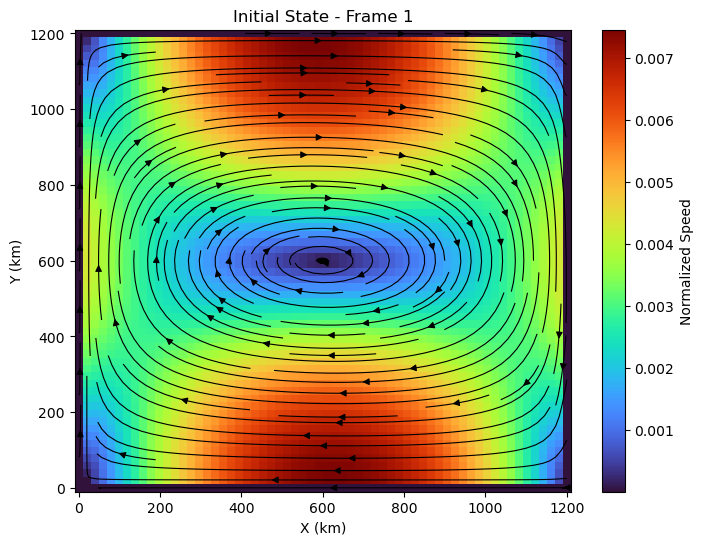

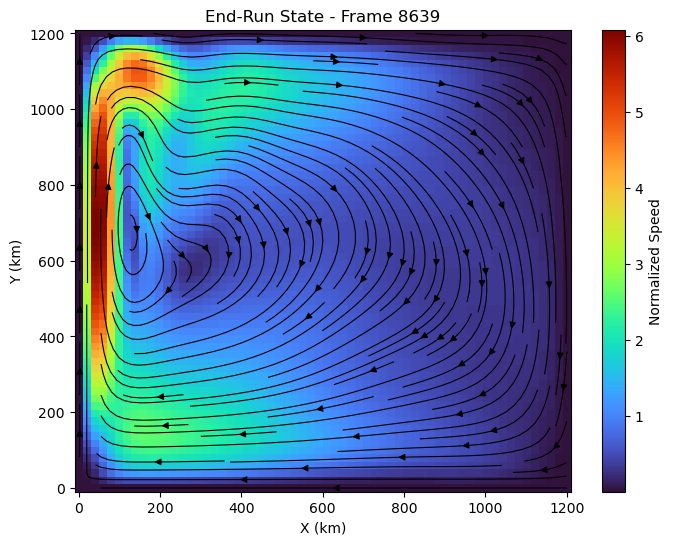

In [6]:
def plot_velocity_frame(data_tensor, frame_idx, title="Ocean Velocity"):
    u = data_tensor[frame_idx, 0].numpy()
    v = data_tensor[frame_idx, 1].numpy()
    
    speed = np.sqrt(u**2 + v**2)
    
    x = np.linspace(0, 1200, 62) 
    y = np.linspace(0, 1200, 62)
    X, Y = np.meshgrid(x, y)

    plt.figure(figsize=(8, 6))
    
    im = plt.pcolormesh(X, Y, speed, cmap='turbo', shading='auto')
    plt.colorbar(im, label='Normalized Speed')
    
    plt.streamplot(X, Y, u, v, color='black', linewidth=0.8, density=1.5)
    
    plt.title(f"{title} - Frame {frame_idx}")
    plt.xlabel('X (km)')
    plt.ylabel('Y (km)')
    plt.show()

plot_velocity_frame(normalized_data, 1, "Initial State")
plot_velocity_frame(normalized_data, 8639, "End-Run State")

## Model Design

I initally started with a small CNN. Instead of predicting the entire next ocean state from scratch, it predicts a correction `delta` and returns `current_state + delta`. This residual setup is useful because adjacent MITgcm snapshots, and thus adjacent predicted state outputs see little change, so the model only needs to learn how the state changes over one forecast step instead of the entire state. 

The loss function is mean squared error between the predicted future state and the MITgcm target state, optimized with Adam.


In [ ]:
# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()

#         #encoder
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
#         self.relu = nn.ReLU()
#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         #decoder
#         self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
#         self.conv4 = nn.Conv2d(32, 3, 3, padding=1)
        
#     def forward(self, x):
#         # Encoder
#         h = self.relu(self.conv1(x))
#         h = self.relu(self.conv2(h))
        
#         # Decoder
#         h = self.relu(self.conv3(h))
#         delta = self.conv4(h)
#         return x + delta

# model = Net()

#### Using the UNet architecture from class, and modifying it to use residuals and fit better with my specific data inputs.

In [34]:
def double_conv(in_ch, out_ch, dilation=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=dilation,
                  dilation=dilation, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=dilation,
                  dilation=dilation, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[32, 64, 128], dilation=1):
        super().__init__()
        
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Formulate the encoder
        self.downs = nn.ModuleList()
        ch_in = in_channels
        for feat in features:
            self.downs.append(double_conv(ch_in, feat))
            ch_in = feat

        # The "bottleneck" also has a double convolutional layer
        self.bottleneck = double_conv(features[-1], features[-1] * 2, dilation=dilation)

        # Formulate the decoder 
        ch_in = features[-1] * 2
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(ch_in, feat, kernel_size=2, stride=2))
            self.ups.append(double_conv(ch_in, feat))
            ch_in = feat

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        x_original = x

        # padding to make it work better for upsampling and downsampling
        x = F.pad(x, (1, 1, 1, 1), mode="replicate")

        # make a list for the skip connections
        skip_connections = []

        # make the downward U section
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # make the bottleneck
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # make the upward U section
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upsample
            skip = skip_connections[idx // 2]
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)

        delta = self.final_conv(x)
        # removing the padding to return to original dims 
        delta = delta[:, :, 1:-1, 1:-1]
        return delta + x_original 

model = UNet(
    in_channels=3,
    out_channels=3,
    features=[32, 64, 128],
)

## Model Training

Train the CNN and track both training and validation loss at every epoch. Plotting the loss curves to see the training progress and check for overfitting.


Using device: mps
Epoch 1/50, Train Loss: 0.003245, Val Loss: 0.000057, Time: 5.85s
Epoch 2/50, Train Loss: 0.000078, Val Loss: 0.000029, Time: 5.80s
Epoch 3/50, Train Loss: 0.000050, Val Loss: 0.000023, Time: 6.03s
Epoch 4/50, Train Loss: 0.000034, Val Loss: 0.000017, Time: 6.16s
Epoch 5/50, Train Loss: 0.000025, Val Loss: 0.000013, Time: 6.15s
Epoch 6/50, Train Loss: 0.000022, Val Loss: 0.000009, Time: 6.14s
Epoch 7/50, Train Loss: 0.000015, Val Loss: 0.000006, Time: 6.22s
Epoch 8/50, Train Loss: 0.000013, Val Loss: 0.000006, Time: 6.17s
Epoch 9/50, Train Loss: 0.000011, Val Loss: 0.000008, Time: 6.20s
Epoch 10/50, Train Loss: 0.000011, Val Loss: 0.000011, Time: 6.16s
Epoch 11/50, Train Loss: 0.000010, Val Loss: 0.000007, Time: 6.17s
Epoch 12/50, Train Loss: 0.000008, Val Loss: 0.000004, Time: 5.85s
Epoch 13/50, Train Loss: 0.000007, Val Loss: 0.000005, Time: 5.78s
Epoch 14/50, Train Loss: 0.000006, Val Loss: 0.000003, Time: 5.73s
Epoch 15/50, Train Loss: 0.000006, Val Loss: 0.000005

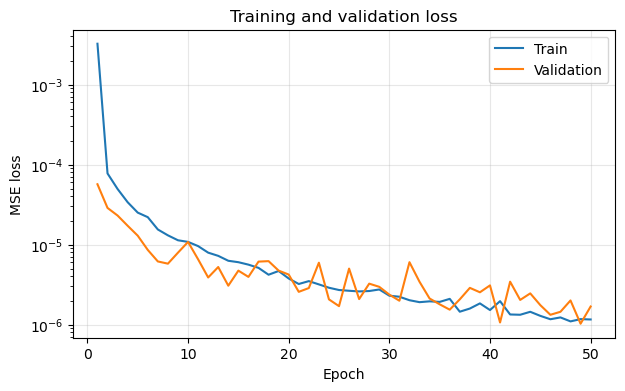

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
history = {"train_loss": [], "val_loss": []}

start_time_total = time.time()
for epoch in range(epochs):
    start_time_epoch = time.time()
    model.train()
    train_loss_sum = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        batch_size = inputs.size(0)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss_sum += loss.item() * batch_size

    train_epoch_loss = train_loss_sum / len(train_loader.dataset)

    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            batch_size = inputs.size(0)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss_sum += loss.item() * batch_size

    val_epoch_loss = val_loss_sum / len(val_loader.dataset)
    history["train_loss"].append(train_epoch_loss)
    history["val_loss"].append(val_epoch_loss)

    epoch_time = time.time() - start_time_epoch
    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Loss: {train_epoch_loss:.6f}, "
        f"Val Loss: {val_epoch_loss:.6f}, "
        f"Time: {epoch_time:.2f}s"
    )

total_time = time.time() - start_time_total
print(f"\nTotal training time: {total_time:.2f}s")

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), history["train_loss"], label="Train")
plt.plot(range(1, epochs + 1), history["val_loss"], label="Validation")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show();

In [27]:
# Save the trained model
torch.save(model.state_dict(), 'barotropic_UNet_model.pt')
print("Model saved to 'barotropic_UNet_model.pt'")

Model saved to 'barotropic_UNet_model.pt'


In [28]:
# Load the trained model
model = UNet()
model.load_state_dict(torch.load('barotropic_UNet_model.pt'))
model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


### Evaluating the Performance
checking the validation MSE loss.

In [29]:
# Evaluate model on validation set
model.eval()
val_mse_sum = 0.0
n_val_samples = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        batch_size = inputs.size(0)

        val_mse_sum += criterion(outputs, targets).item() * batch_size
        n_val_samples += batch_size
        
        all_predictions.append(outputs.cpu())
        all_targets.append(targets.cpu())

val_loss = val_mse_sum / n_val_samples
print(f"Validation MSE: {val_loss:.6f}")

# Concatenate all predictions and targets for later plotting/analysis.
all_predictions = torch.cat(all_predictions, dim=0)
all_targets = torch.cat(all_targets, dim=0)


Validation MSE: 0.000003


An important baseline when predicting ocean state's is the persistence model, which is simply predicting the future state to be the same; i.e. no change. Since the ocean state changes very little in short time steps, in theory this is a strong baseline, and easy for a model to want to conform to just 0 change to minimize error. Thus it is important for the model to beat this baseline to show something meaningful is being learned.

Persistence MSE: 0.000008
Model MSE:       0.000003
MSE skill vs persistence: 65.0%


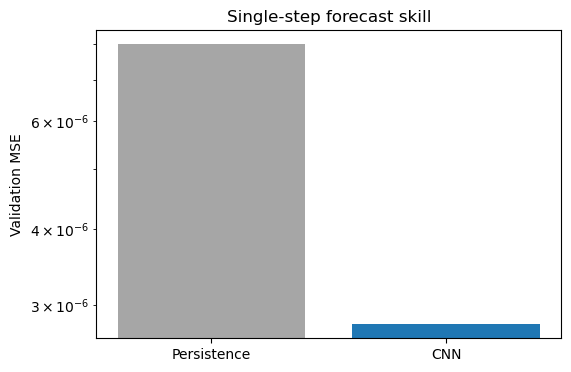

In [30]:
# Persistence baseline: assume the future state is identical to the current state.
# This tests whether the CNN beats a baseline persistence model 
persistence_mse_sum = 0.0
n_val_samples = 0

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        batch_size = inputs.size(0)

        persistence_mse_sum += criterion(inputs, targets).item() * batch_size
        n_val_samples += batch_size

persistence_mse = persistence_mse_sum / n_val_samples
mse_skill = 1 - (val_loss / persistence_mse)

print(f"Persistence MSE: {persistence_mse:.6f}")
print(f"Model MSE:       {val_loss:.6f}")
print(f"MSE skill vs persistence: {100 * mse_skill:.1f}%")

plt.figure(figsize=(6, 4))
plt.bar(["Persistence", "CNN"], [persistence_mse, val_loss], color=["0.65", "tab:blue"])
plt.yscale("log")
plt.ylabel("Validation MSE")
plt.title("Single-step forecast skill")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## Analysis: Autoregressive Testing

Ultimately I want this model to be able to work autoregressively, where the model's own predictions are repeatedly fed back in as the input to do step-wise forecasting, long term into the future. The difficulty with this is while error may be small between one step, the error can compound over several steps and the error can blow up, making the results become quite bad. 


In [31]:
# Run autoregressive predictions across the first 12 months,
# correctly accounting for stride.
STRIDE = 6                       # must match what you used in MitgcmDataset
START_HOUR = 24                  # skip the all-zeros initial spin-up frame

hours_per_month = 24 * 30
months_to_predict = 12
hours_to_predict = months_to_predict * hours_per_month   # 8640 hours of *simulated time*
n_steps = hours_to_predict // STRIDE                      # = 1440 model steps

model.eval()

# Start from a real, spun-up frame (not the zero initial condition).
current_frame = normalized_data[START_HOUR].unsqueeze(0).to(device)
autoregressive_predictions = [current_frame.cpu().squeeze(0)]

print(f"Running {n_steps} model steps "
      f"(stride={STRIDE}h -> {hours_to_predict} simulated hours, ~{months_to_predict} months)...")

with torch.no_grad():
    for step in range(n_steps):
        next_frame = model(current_frame)
        autoregressive_predictions.append(next_frame.cpu().squeeze(0))
        current_frame = next_frame

        # Print every simulated month
        sim_hour = (step + 1) * STRIDE
        if sim_hour % hours_per_month == 0:
            print(f"  Predicted {sim_hour} simulated hours "
                  f"({sim_hour // hours_per_month} months)")

autoregressive_predictions = torch.stack(autoregressive_predictions)
print(f"Autoregressive predictions shape: {autoregressive_predictions.shape}")
print(f"(Timesteps, Channels, Height, Width)")

# Compare at key months. Convert "simulated hour" to:
#   - prediction index: how many model steps from the start
#   - actual index:     hourly index into normalized_data
key_months = [1, 3, 6, 11]
print()
print("Mean squared errors over time:")
for month in key_months:
    sim_hour   = month * hours_per_month                  # e.g. month 3 -> hour 2160
    pred_idx   = sim_hour // STRIDE                        # e.g. 360 model steps
    actual_idx = START_HOUR + sim_hour                    # hourly index, offset by spin-up

    if pred_idx < len(autoregressive_predictions) and actual_idx < len(normalized_data):
        pred_frame   = autoregressive_predictions[pred_idx]
        actual_frame = normalized_data[actual_idx]
        mse = torch.mean((pred_frame - actual_frame) ** 2).item()
        print(f"  Month {month:2d} (sim hour {sim_hour}, pred_idx {pred_idx}, "
              f"actual_idx {actual_idx}): MSE = {mse:.6f}")


Running 1440 model steps (stride=6h -> 8640 simulated hours, ~12 months)...
  Predicted 720 simulated hours (1 months)
  Predicted 1440 simulated hours (2 months)
  Predicted 2160 simulated hours (3 months)
  Predicted 2880 simulated hours (4 months)
  Predicted 3600 simulated hours (5 months)
  Predicted 4320 simulated hours (6 months)
  Predicted 5040 simulated hours (7 months)
  Predicted 5760 simulated hours (8 months)
  Predicted 6480 simulated hours (9 months)
  Predicted 7200 simulated hours (10 months)
  Predicted 7920 simulated hours (11 months)
  Predicted 8640 simulated hours (12 months)
Autoregressive predictions shape: torch.Size([1441, 3, 62, 62])
(Timesteps, Channels, Height, Width)

Mean squared errors over time:
  Month  1 (sim hour 720, pred_idx 120, actual_idx 744): MSE = 0.015628
  Month  3 (sim hour 2160, pred_idx 360, actual_idx 2184): MSE = 0.391177
  Month  6 (sim hour 4320, pred_idx 720, actual_idx 4344): MSE = 35.664009
  Month 11 (sim hour 7920, pred_idx 1320

#### Looking at magnitudes of velocity and how they compare, actual vs predicted, and how the error grows over time.


Autoregressive Predictions vs MITgcm:



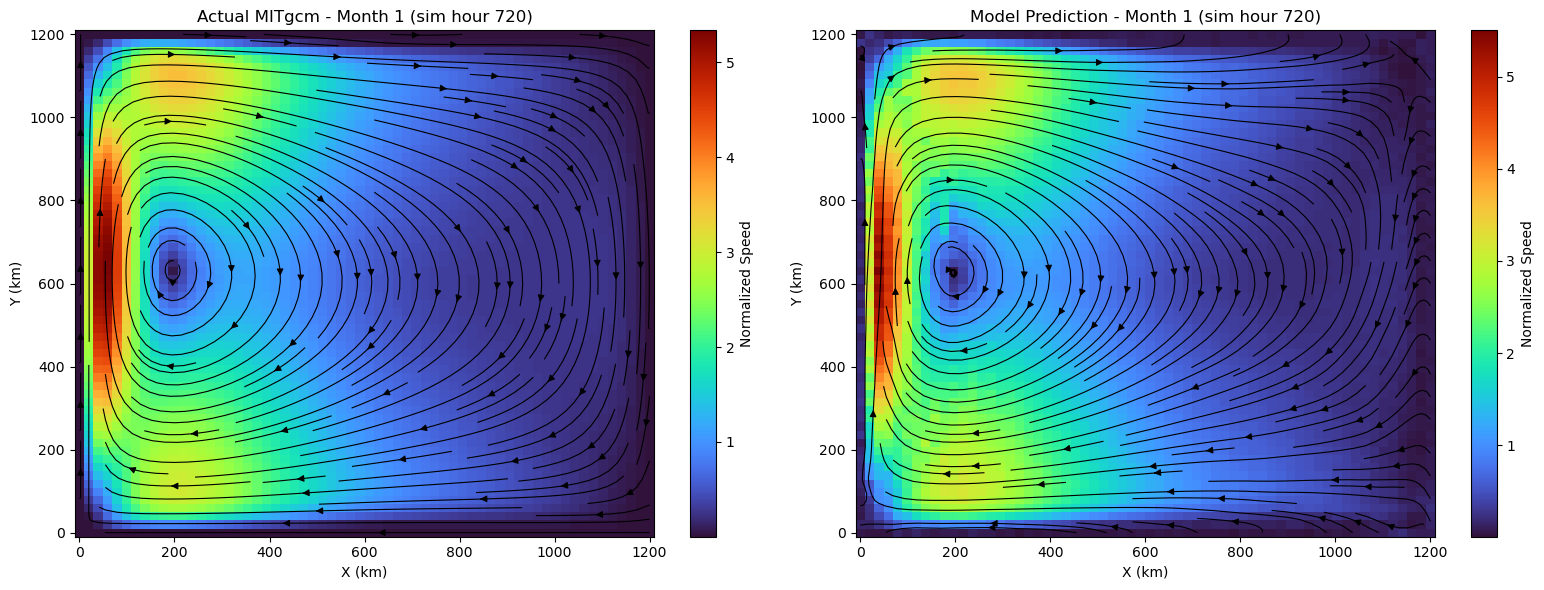

Month 1 (sim hour 720) - U MSE: 0.015014  V MSE: 0.011882  speed MSE: 0.012949



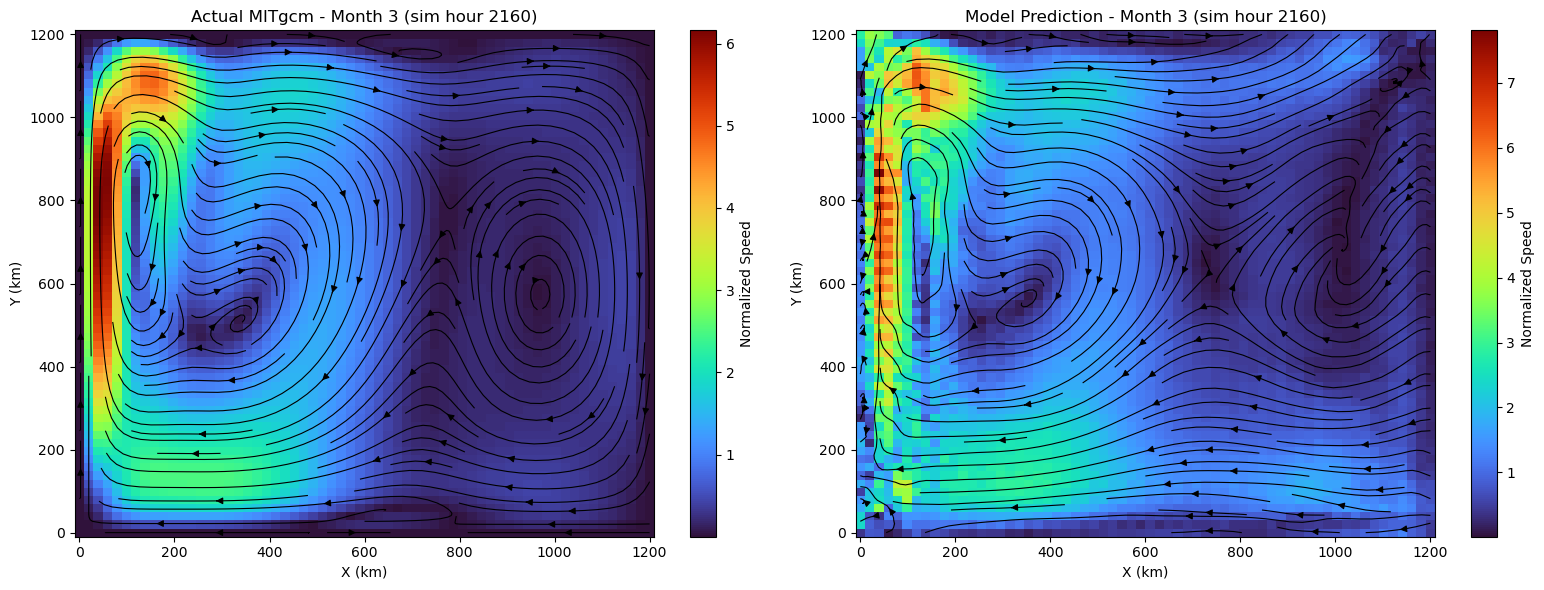

Month 3 (sim hour 2160) - U MSE: 0.462311  V MSE: 0.183662  speed MSE: 0.329224



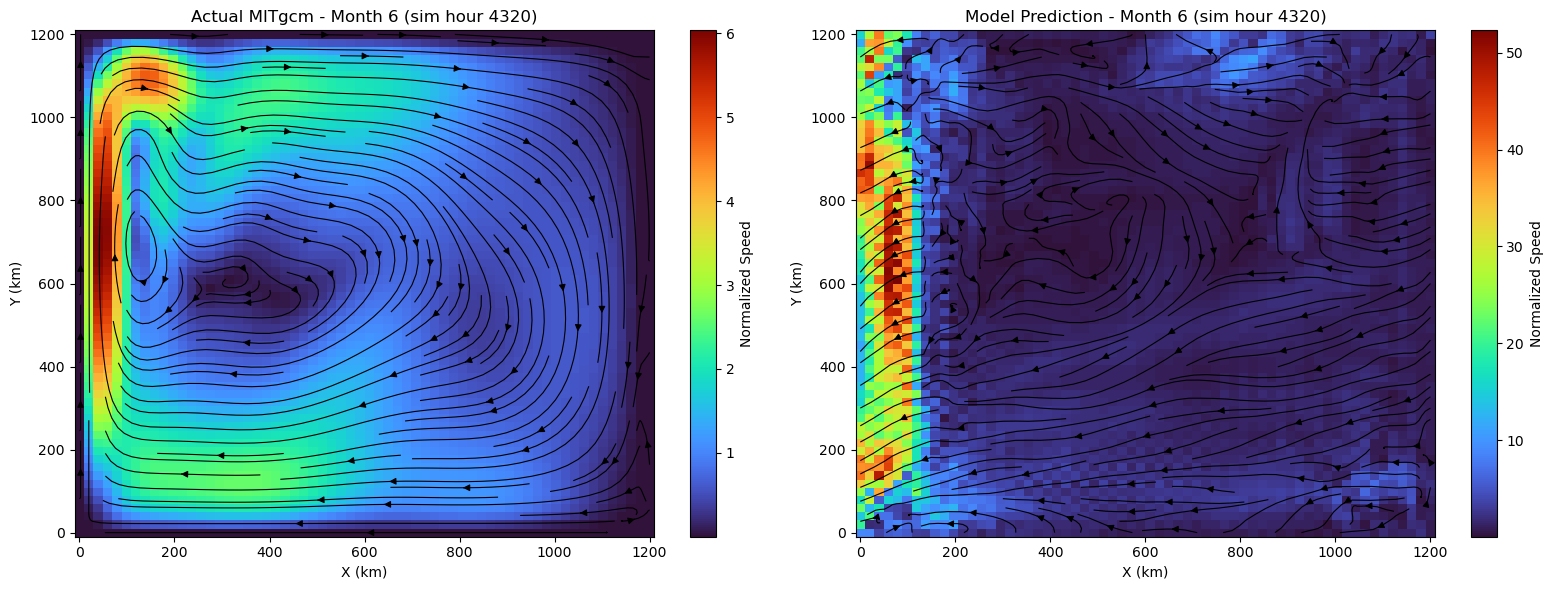

Month 6 (sim hour 4320) - U MSE: 68.315132  V MSE: 32.603123  speed MSE: 78.695045



In [32]:
# Visualize autoregressive predictions at key timepoints
STRIDE = 6                          # must match the dataset and cell 11
START_HOUR = 24                     # must match cell 11
hours_per_month = 24 * 30

def plot_autoregressive_comparison(predictions, actual_data, pred_idx, actual_idx, label):
    pred_frame   = predictions[pred_idx]
    actual_frame = actual_data[actual_idx]

    pred_u   = pred_frame[0].numpy();   pred_v   = pred_frame[1].numpy()
    actual_u = actual_frame[0].numpy(); actual_v = actual_frame[1].numpy()

    pred_speed   = np.sqrt(pred_u**2   + pred_v**2)
    actual_speed = np.sqrt(actual_u**2 + actual_v**2)

    x = np.linspace(0, 1200, 62)
    y = np.linspace(0, 1200, 62)
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im0 = axes[0].pcolormesh(X, Y, actual_speed, cmap='turbo', shading='auto')
    axes[0].streamplot(X, Y, actual_u, actual_v, color='black', linewidth=0.8, density=1.5)
    axes[0].set_title(f"Actual MITgcm - {label}")
    axes[0].set_xlabel('X (km)'); axes[0].set_ylabel('Y (km)')
    plt.colorbar(im0, ax=axes[0], label='Normalized Speed')

    im1 = axes[1].pcolormesh(X, Y, pred_speed, cmap='turbo', shading='auto')
    axes[1].streamplot(X, Y, pred_u, pred_v, color='black', linewidth=0.8, density=1.5)
    axes[1].set_title(f"Model Prediction - {label}")
    axes[1].set_xlabel('X (km)'); axes[1].set_ylabel('Y (km)')
    plt.colorbar(im1, ax=axes[1], label='Normalized Speed')

    plt.tight_layout()
    plt.show()

    u_mse     = np.mean((pred_u - actual_u) ** 2)
    v_mse     = np.mean((pred_v - actual_v) ** 2)
    speed_mse = np.mean((pred_speed - actual_speed) ** 2)
    print(f"{label} - U MSE: {u_mse:.6f}  V MSE: {v_mse:.6f}  "
          f"speed MSE: {speed_mse:.6f}")
    print()


# Visualize at meaningful simulated times (months of model time, not step counts).
print()
print("Autoregressive Predictions vs MITgcm:")
print()
for month in [1, 3, 6, 12]:
    sim_hour   = month * hours_per_month                # months -> hours of sim time
    pred_idx   = sim_hour // STRIDE                     # which model step that is
    actual_idx = START_HOUR + sim_hour                  # which hourly index in normalized_data

    if pred_idx < len(autoregressive_predictions) and actual_idx < len(normalized_data):
        plot_autoregressive_comparison(
            autoregressive_predictions, normalized_data,
            pred_idx, actual_idx,
            f"Month {month} (sim hour {sim_hour})",
        )


#### Doing the same but for sea-surface height, which is very predictive of ocean state and thus important. Also looking at the spatial error. 


Autoregressive Eta Predictions vs MITgcm:



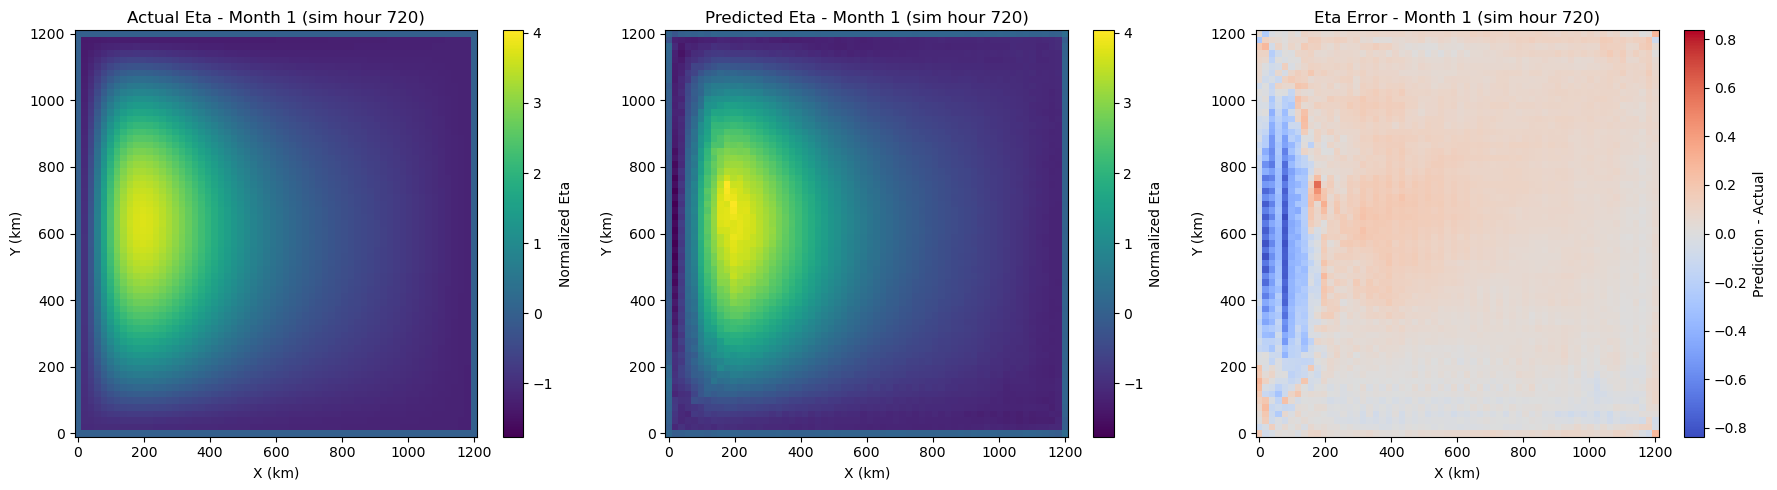

Month 1 (sim hour 720) - Eta MSE: 0.019987



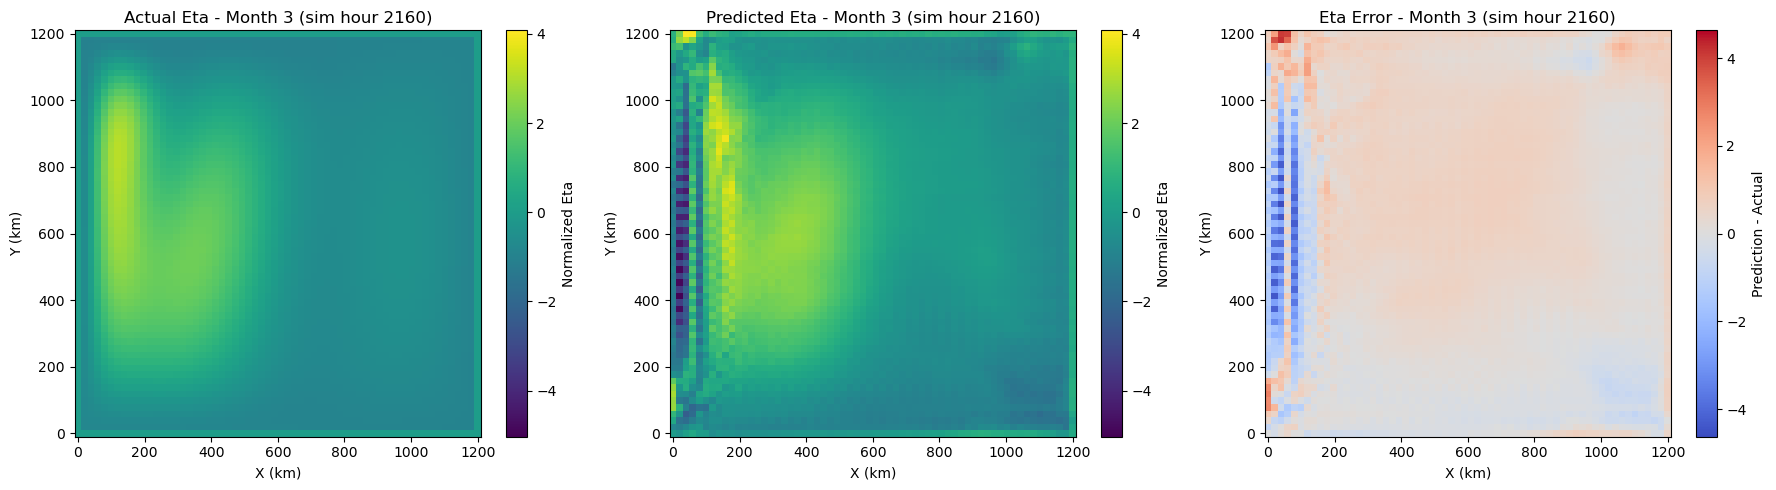

Month 3 (sim hour 2160) - Eta MSE: 0.527557



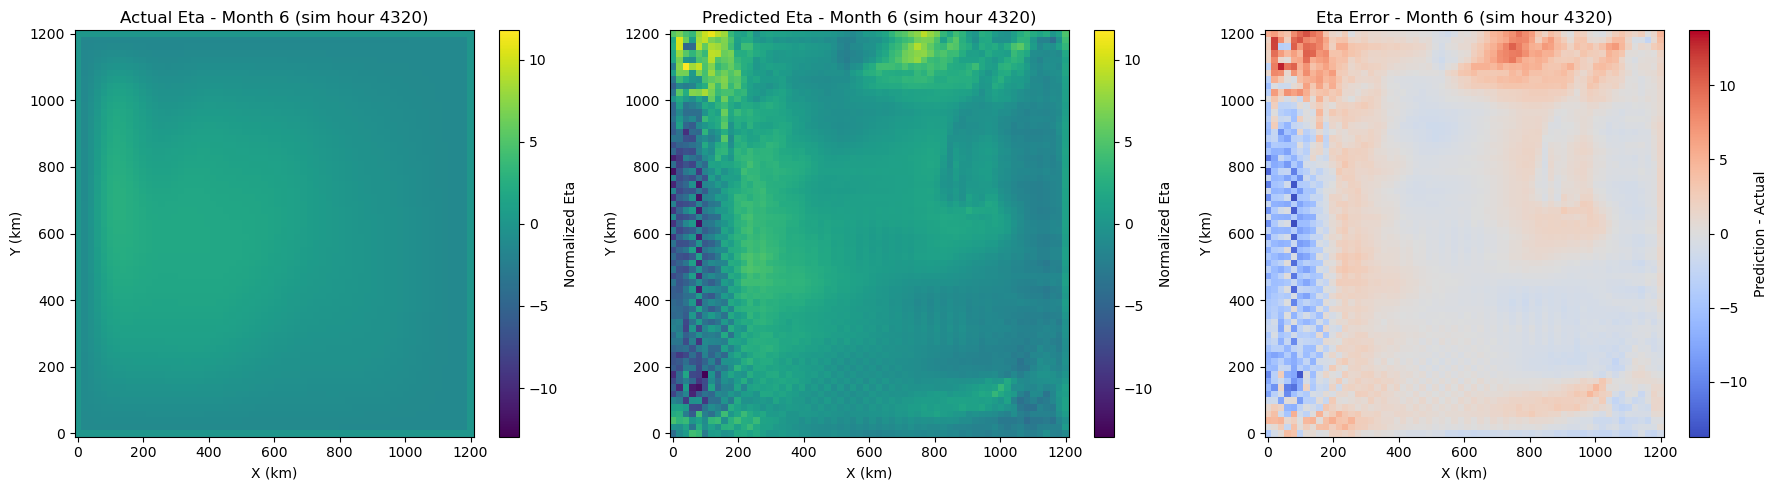

Month 6 (sim hour 4320) - Eta MSE: 6.073761



In [33]:
# Visualize autoregressive Eta predictions at key timepoints.
ETA_CHANNEL = 2
STRIDE = 6
START_HOUR = 24
hours_per_month = 24 * 30

def plot_eta_autoregressive_comparison(predictions, actual_data, pred_idx, actual_idx, label):
    pred_eta = predictions[pred_idx, ETA_CHANNEL].numpy()
    actual_eta = actual_data[actual_idx, ETA_CHANNEL].numpy()
    eta_error = pred_eta - actual_eta
    eta_mse = np.mean(eta_error ** 2)

    x = np.linspace(0, 1200, 62)
    y = np.linspace(0, 1200, 62)
    X, Y = np.meshgrid(x, y)

    eta_vmin = min(actual_eta.min(), pred_eta.min())
    eta_vmax = max(actual_eta.max(), pred_eta.max())
    err_abs_max = np.max(np.abs(eta_error))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].pcolormesh(X, Y, actual_eta, cmap='viridis', shading='auto',
                             vmin=eta_vmin, vmax=eta_vmax)
    axes[0].set_title(f"Actual Eta - {label}")
    axes[0].set_xlabel('X (km)')
    axes[0].set_ylabel('Y (km)')
    plt.colorbar(im0, ax=axes[0], label='Normalized Eta')

    im1 = axes[1].pcolormesh(X, Y, pred_eta, cmap='viridis', shading='auto',
                             vmin=eta_vmin, vmax=eta_vmax)
    axes[1].set_title(f"Predicted Eta - {label}")
    axes[1].set_xlabel('X (km)')
    axes[1].set_ylabel('Y (km)')
    plt.colorbar(im1, ax=axes[1], label='Normalized Eta')

    im2 = axes[2].pcolormesh(X, Y, eta_error, cmap='coolwarm', shading='auto',
                             vmin=-err_abs_max, vmax=err_abs_max)
    axes[2].set_title(f"Eta Error - {label}")
    axes[2].set_xlabel('X (km)')
    axes[2].set_ylabel('Y (km)')
    plt.colorbar(im2, ax=axes[2], label='Prediction - Actual')

    plt.tight_layout()
    plt.show()

    print(f"{label} - Eta MSE: {eta_mse:.6f}")
    print()


print()
print("Autoregressive Eta Predictions vs MITgcm:")
print()
for month in [1, 3, 6, 12]:
    sim_hour = month * hours_per_month
    pred_idx = sim_hour // STRIDE
    actual_idx = START_HOUR + sim_hour

    if pred_idx < len(autoregressive_predictions) and actual_idx < len(normalized_data):
        plot_eta_autoregressive_comparison(
            autoregressive_predictions,
            normalized_data,
            pred_idx,
            actual_idx,
            f"Month {month} (sim hour {sim_hour})",
        )


### Analysis

The UNet emulator clearly did my better than my previous small CNN, with much better looking autoregressive results and better validation MSE, though I did not include those results in this notebook to focus on the UNet results.

The UNet emulator, using 6 hour timesteps, did learn accurate short-term transitions between steps, shown by having a validation MSE of 0.000003, which is about 65% better than the persistence baseline MSE of 0.000008. This shows that the model is learning something meaningful about how the ocean state changes over time, rather than just copying the input.

However, while much improved, my UNet architecture still shows error blowing up over the autoregressive progression, clearly getting worse over time, with MSE of 0.0156 after 1 month, 0.391 after 3 months, and 35.66 after 6 months. This shows that while the model does initially well, reflecting short term accurate predictions, the errors compound over time and still does not preserve long-term accuracy, and thus not preserving the long-term ocean dynamics from the original ocean simulation. This can also be seen in the plots over time of velocity and Eta, with error accumulating and diverging significantly from the true output by 3-6 months into the prediction.

To answer my scientific question, I would say the short answer is: there is strong potential, but more work needs to be done to improve long-term autoregressive performance. This UNet architecture is a promising start, with some fairly accurate outputs between 1-3 months, but long-term the performance degrades significantly. Future work could include continuing to experiment with the architecture, such as changing the layers and connections, and also how I am splitting the data for training and testing. 